In [1]:
# IMPORT LIBRERIE
import numpy as np
from pathlib import Path
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import random_statevector
from qiskit.result import marginal_counts

# Il simulatore
sim = AerSimulator()

In [2]:
# SALVA IMMAGINI, riproducibilità

# Semi per la riproducibilità
SEME_STATO = 42         # stato casuale da teletrasportare
SEME_SIMULATORE = 42    # esiti casuali delle misure
N_SHOTS = 1024

# Indici dei qubit con la notazione del Capitolo 3: C -> q0, A -> q1, B -> q2
C, A, B = 0, 1, 2

# Salvataggio delle figure (in PDF, per LaTeX)
CARTELLA = Path("immagini")
CARTELLA.mkdir(exist_ok=True)

def salva(fig, nome):
    fig.savefig(CARTELLA / f"{nome}.pdf", bbox_inches="tight")
    return fig

In [3]:
# Sia qc il QuantumCircuit, ossia il "contenitore" che include tutti e tre i qubit insieme a tutte le porte e le misure che applichi

# Creazione della coppia entangled di Telamon (stato di Bell):
# Si parte da |00>, si applica H, e poi CNOT, usando come control il generico a e come target b
def create_bell_pair(qc, a, b):
    qc.h(a)          # Hadamard sul primo qubit                         =>   |00> => (|0>+|1>)/sqrt(2) x |0> = (|00>+|10>)/sqrt(2)
    qc.cx(a, b)      # CNOT usando a come controllo e b come target     =>           (|00> + |11>)/sqrt(2)   =   |Phi^+_AB>

# Applicazione da parte di Alice dei Gate del protocollo di Teletrasporto Quantistico, CNOT e H, in questo ordine
def alice_gates(qc, c, a):
    qc.cx(c, a)            # CNOT da C ad A: |Psi0> -> |Psi1>
    qc.h(c)                # H su C:         |Psi1> -> |Psi2>

# Misura 
def measure_and_send(qc, c, a, m_C, m_A):
    qc.barrier()
    qc.measure(c, m_C)
    qc.measure(a, m_A)

# Operazione di BOB, I, X, Z, XZ
def bob_gates(qc, b, m_C, m_A):
    with qc.if_test((m_A, 1)):
        qc.x(b)   # X se m_A = 1
    with qc.if_test((m_C, 1)):
        qc.z(b)   # Z se m_C = 1

alpha = (0.18817375576319426+0.4634306030554158j)
beta  = (-0.6422275881713418+0.5808325393650813j)
verifica normalizzazione (deve dare ~1.0): 0.9999999999999999


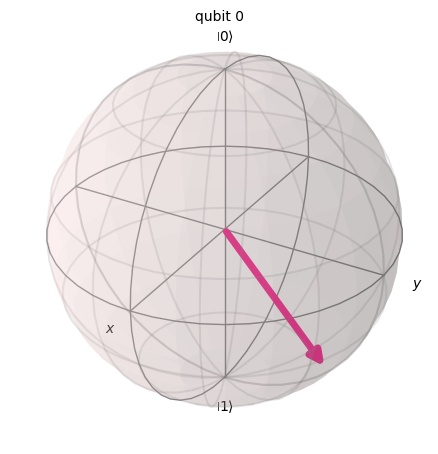

In [4]:
# SETUP
# A questo punto inizializziamo lo stato che Alice vuole teletrasportare a Bob in uno stato randomico
# Come sappiamo sulla sfera di Bloch vale: |psi> = cos(theta/2)|0> + e^{i*phi} sin(theta/2)|1>

# Stato da teletrasportare |psi_C> = alpha|0> + beta|1>, scelto a caso:

# Fissiamo alpha e beta, i coefficienti creati da random_statevector
psi = random_statevector(2, seed=SEME_STATO)
alpha, beta = psi.data
print(f"alpha = {alpha}")
print(f"beta  = {beta}")
print("verifica normalizzazione (deve dare ~1.0):", abs(alpha)**2 + abs(beta)**2)

# Siccome |alpha| = cos(theta/2), allora theta è
theta = 2 * np.arccos(abs(alpha))
# e poniamo phi come la differenza tra beta e alfa, ciò elimina la fase globale e lascia solo quella relativa 
phi = np.angle(beta) - np.angle(alpha)

plot_bloch_multivector(psi)

# Per ora abbiamo solo un vettore di numeri (nessun qubit fisico esiste
# ancora): ci servirà come "bersaglio" da confrontare alla fine, e per
# calcolare gli angoli (theta, phi) con cui costruirlo davvero su un qubit
# nello STEP 1

# NB
# Il motivo per cui, nel protocollo di teletrasporto, noi conosciamo theta e phi (mentre nella teoria che conosciamo "Alice  
# ha uno stato sconosciuto") è pratico. Vogliamo verificare che il teletrasporto funzioni e quindi dobbiamo sapere qual è lo stato bersaglio 
# da confrontare alla fine. Fisicamente, però, il punto del protocollo resta intatto: una volta che q0 è stato preparato 
# (da chiunque, con qualunque circuito), Bob riceve quello stato senza che nessuno debba mai dirgli quali sono theta e phi — 
# la correzione avviene solo sulla base dei 2 bit classici, non serve conoscere lo stato per teletrasportarlo.

salva(plot_bloch_multivector(psi), "bloch_psi_iniziale")

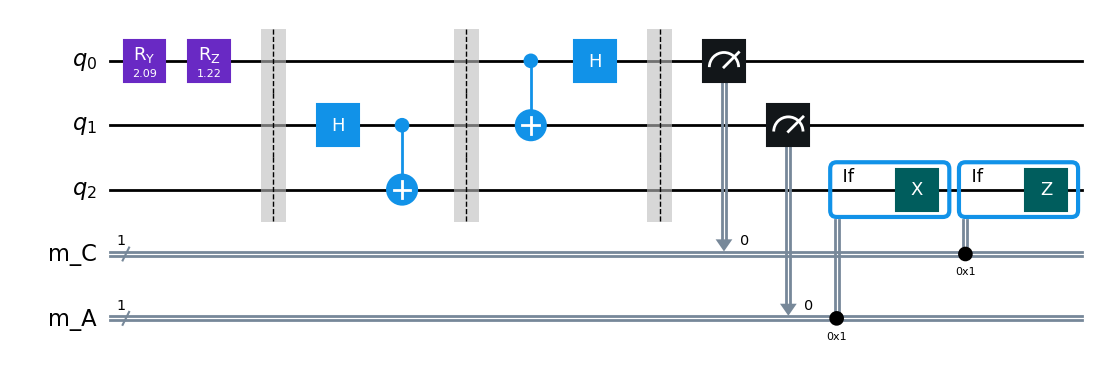

In [5]:
qr = QuantumRegister(3, name="q")          # I 3 qubit vengono creati tutti insieme, in un colpo solo in questa riga => indicizzazione (0, 1, 2)
m_C = ClassicalRegister(1, name="m_C")
m_A = ClassicalRegister(1, name="m_A")
qc = QuantumCircuit(qr, m_C, m_A)


##################################

## STEP 1
# Prepariamo lo stato |psi> sul qubit di Alice (q0), partendo da |0>.
# RY porta |0> in cos(theta/2)|0> + sin(theta/2)|1> (ampiezze reali corrette);
# RZ aggiunge poi la fase relativa e^{i*phi} sulla componente |1>.
# Dopo queste due righe, q0 e' fisicamente nello stato psi.

qc.ry(theta, C)                             # applica RY al qubit di indice 0
qc.rz(phi, C)                               # applico RZ al qubit di indice 0  => ottengo allora q0 nello stato |psi>, quello che voglio teletrasportare
qc.barrier()

#################################

## STEP 2
# Telamon crea la coppia entangled di Bell (|00> + |11>) / sqrt(2)

create_bell_pair(qc, A, B)
qc.barrier()

#################################

## STEP 3
# Alice applica CNOT e H come vuole il protocollo, successivamente misura q0 e q1 
# => il collasso produce i 2 bit classici (m_C, m_A) e li invia a Bob

alice_gates(qc, C, A)
measure_and_send(qc, C, A, m_C, m_A)

#################################

## STEP 4
# Bob, sulla base dei 2 bit ricevuti, applica la correzione di Pauli
# (I, X, Z o XZ) al proprio qubit q2.
bob_gates(qc, B, m_C, m_A)

################################

## SALVA IMMAGINE
fig2 = qc.draw('mpl', style='textbook')
salva(fig2, "circuito_teletrasporto1")

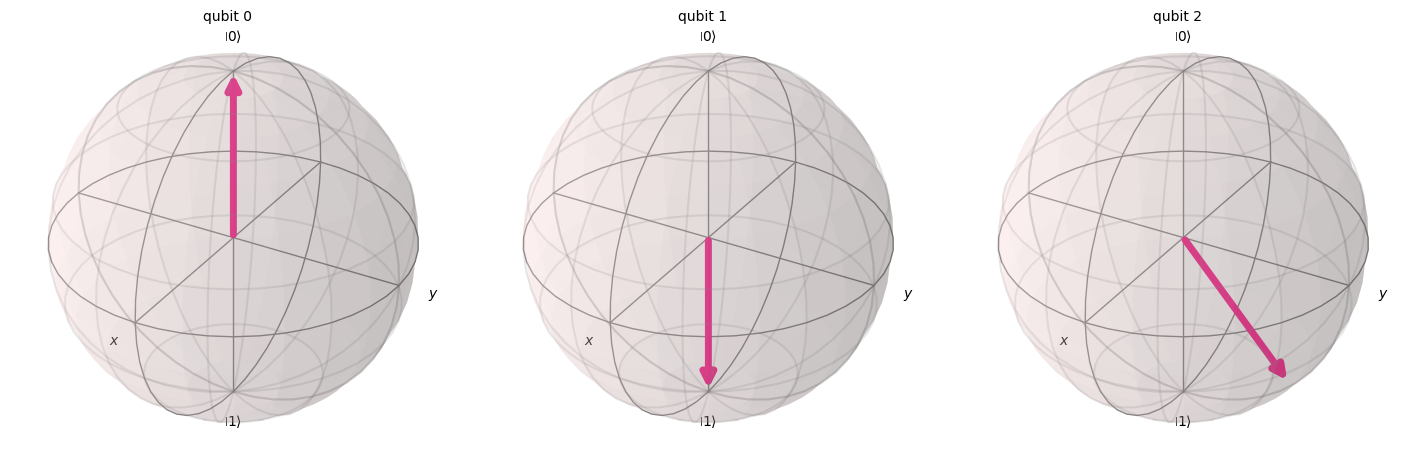

In [6]:
## STEP 5
# Verifica esatta (un singolo "shot"): eseguiamo il circuito, che include
# già una misura reale (dentro measure_and_send). 
# Quindi save_statevector() cattura lo stato completo dei 3 qubit DOPO quella misura casuale e dopo
# la correzione di Bob. Se il protocollo ha funzionato, la sfera di Bloch
# di q2 qui sotto dovrà coincidere esattamente con quella di psi (trovata nel SETUP),
# qualunque sia stato l'esito casuale della misura di Alice.

qc.save_statevector()
out_vector = sim.run(qc, seed_simulator=SEME_SIMULATORE).result().get_statevector()
plot_bloch_multivector(out_vector)

## SALVA IMMAGINE
salva(plot_bloch_multivector(out_vector), "bloch_psi_tot")

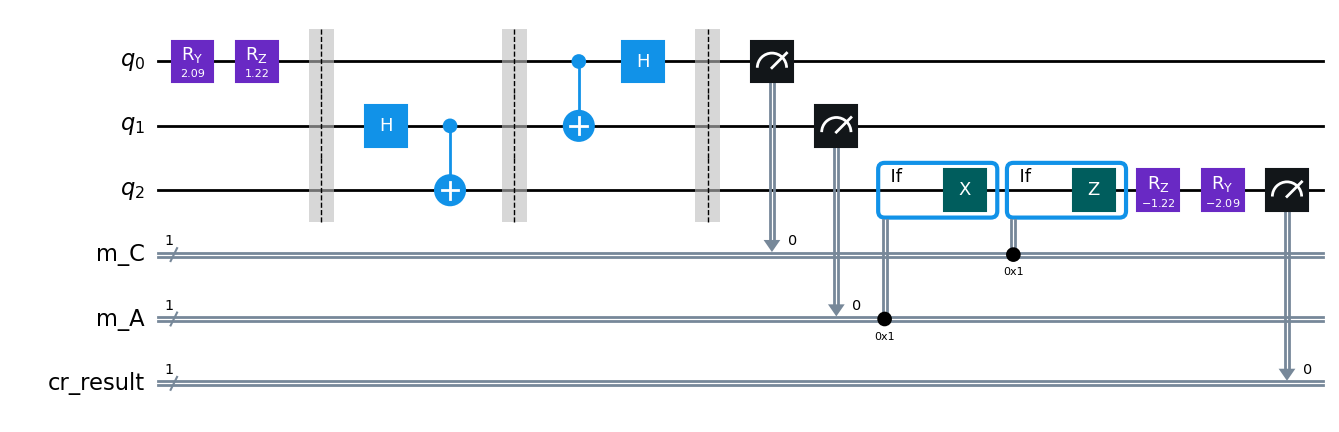

In [7]:
## STEP 6
# Ricreiamo il circuito
# Ripetiamo quindi identici gli STEP 1-4 (preparazione, entanglement,
# misura di Bell, correzione di Bob)
qr = QuantumRegister(3, name="q")          
m_C = ClassicalRegister(1, name="m_C")
m_A = ClassicalRegister(1, name="m_A")
qc = QuantumCircuit(qr, m_C, m_A)

qc.ry(theta, C)
qc.rz(phi, C)
qc.barrier()

create_bell_pair(qc, A, B)
qc.barrier()

alice_gates(qc, C, A)
measure_and_send(qc, C, A, m_C, m_A)
bob_gates(qc, B, m_C, m_A)

####################################

## STEP 7
# A questo punto se tutto ha funzionato, q2 è esattamente nello stato psi.
# Applichiamo ora l'inverso della preparazione fatta allo STEP prima (stessi
# angoli, segno opposto, ordine invertito): se q2 era davvero psi, questa
# operazione lo riporta esattamente a |0>.

qc.rz(-phi, B)
qc.ry(-theta, B)

####################################

## STEP 8
# Aggiungiamo un terzo registro classico per leggere il risultato di q2:
# se il teletrasporto ha funzionato, la misura darà sempre 0.

cr_result = ClassicalRegister(1, name="cr_result")
qc.add_register(cr_result)
qc.measure(B, cr_result)
fig2 = qc.draw('mpl', style='textbook')

## SALVA IMMAGINE
salva(fig2, "circuito_teletrasporto2")

In [8]:
## STEP 9
# Ripetiamo l'intero esperimento 1024 volte (1024 ripetizioni indipendenti,
# ciascuno con un esito casuale diverso della misura di Bell di Alice).
# transpile() traduce le porte di alto livello (RY, RZ, i blocchi if_test)
# nel set di gate elementari che il simulatore sa eseguire nativamente.

from qiskit.result import marginal_counts

t_qc = transpile(qc, sim)
counts = sim.run(t_qc, shots= N_SHOTS, seed_simulator=SEME_SIMULATORE).result().get_counts()
print(counts)
plot_histogram(counts)

###################################

##STEP 10
# counts contiene la distribuzione congiunta dei 3 bit classici
# (m_C, m_A, cr_result). marginal_counts isola solo cr_result (indice
# globale 2), sommando su tutti i possibili esiti di m_C/m_A: e' la
# probabilità di successo del teletrasporto, indipendentemente da quale
# dei 4 rami di Bell sia occorso in ciascuno shot.

risultato_finale = marginal_counts(counts, [2])  # indice globale 2 = cr_result
tasso_errore = 100 * risultato_finale.get('1', 0) / sum(risultato_finale.values())
print(f"Tasso di errore: {tasso_errore:.3f}%")

# viene dalla misura dei qubit: {'q2 q1 q0': n volte} = ovvero in bit classici {'cr_result m_A m_C': n volte}

{'0 0 1': 254, '0 1 0': 278, '0 0 0': 239, '0 1 1': 253}
Tasso di errore: 0.000%


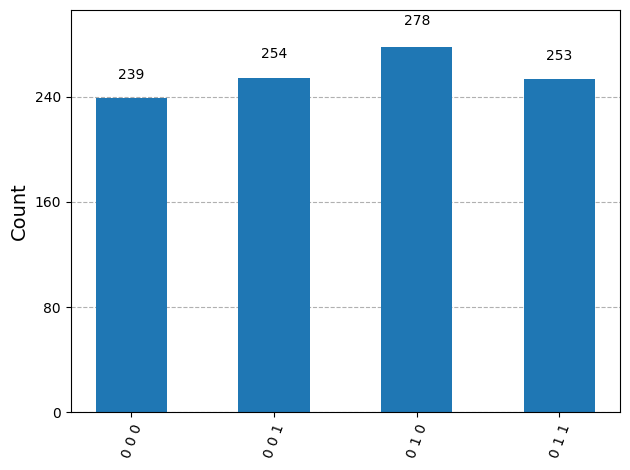

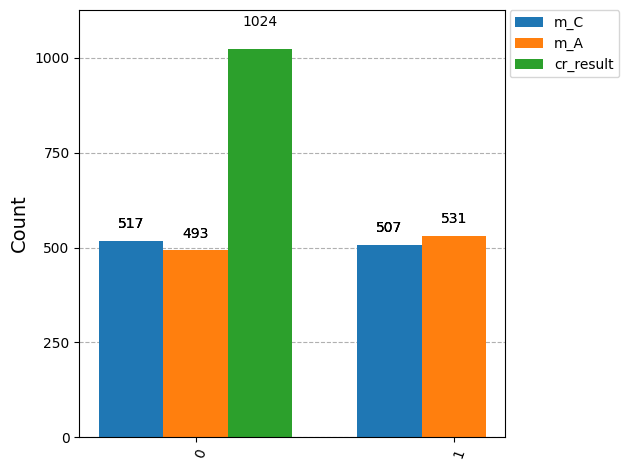

In [9]:
## STEP 11
# ISTOGRAMMA

qubit_counts = [marginal_counts(counts, [i]) for i in range(3)]

# ISTOGRAMMA 1: conteggi congiunti dei quattro esiti (chiavi 'cr_result m_A m_C')
display(salva(plot_histogram(counts), "istogramma_conteggi"))

# L'istogramma2 mostra:
# In verde     => cr_result => è la misura di Bob sul qubit B (q2) => sono tutti 0 (1024) (giusto torna lo stato che Alice voleva inviargli)
# In blu       => m_C       => sono le misure di Alice sul qubit C (q0) => circa 50% delle volte fa 0, l'altro 50% fa 1 
# In arancione => m_A       => sono le misure di Alice sul qubit A (q_1) => circa 50% delle volte fa 0, l'altro 50% fa 1
# ISTOGRAMMA 2: quante volte ciascun bit (m_C, m_A, cr_result) vale 0 e quante 1

# I risultati ottenuti sono {'0 0 1': n1, '0 0 0': n2, '0 1 1': n3, '0 1 0': n4} con {'cr_result m_A m_C': n volte} =  {'q2 q1 q0': n volte}

# cr_result (1) = 0                     # MAI
# cr_result (0) = n1 + n2 + n3 + n4
# m_C (1) = n1 + n3
# m_C (0) = n2 + n4
# m_A (1) = n3 + n4
# m_A (0) = n1 + n2
display(salva(plot_histogram(qubit_counts, legend=['m_C', 'm_A', 'cr_result']), "istogramma_marginali"))


In [10]:
# STEP FINALE => verifica statistica

## Verifica statistica: le fluttuazioni di m_C/m_A sono compatibili con un 50/50 teorico
## Controllo di consistenza statistica dei risutlati di Alice

m_C_counts = marginal_counts(counts, [0])
m_A_counts = marginal_counts(counts, [1])

n_shots = sum(m_C_counts.values())
atteso = n_shots / 2
sigma = np.sqrt(n_shots * 0.5 * 0.5)  # deviazione standard attesa per una binomiale(n, 0.5)

for nome, c in [('m_C', m_C_counts), ('m_A', m_A_counts)]:
    osservato_1 = c.get('1', 0)
    scarto_in_sigma = (osservato_1 - atteso) / sigma
    print(f"{nome}: osservato {osservato_1}/{n_shots} volte '1' "
          f"(atteso {atteso:.0f} ± {sigma:.1f}) -> scarto di {scarto_in_sigma:+.2f} sigma")

# Il risultato entro le 2 sigma conferma che la distribuzione osservata è statisticamente compatibile con un 50/50 teorico


m_C: osservato 507/1024 volte '1' (atteso 512 ± 16.0) -> scarto di -0.31 sigma
m_A: osservato 531/1024 volte '1' (atteso 512 ± 16.0) -> scarto di +1.19 sigma


In [11]:
## NOTE AI
# Il codice del protocollo è adattato dal Qiskit Textbook (IBM). L'aggiornamento alle API correnti e la correzione di un problema 
# di compatibilità con l'ambiente locale sono stati sviluppati con l'assistenza di un modello linguistico (Claude, Anthropic), 
# sotto la mia supervisione e verifica sperimentale